In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\GAMING 3\Desktop\py\Dataset.csv"
df = pd.read_csv(path)

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

Task1: Top Cuisines

Determine the top three most common cuisines in the dataset.

In [4]:
print(df.shape)
print(df.columns)

(9551, 22)
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', '@dropdown'],
      dtype='object')


In [ ]:
print(df["Cuisines"])

0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
                      ...               
9546                             Turkish
9547     World Cuisine, Patisserie, Cafe
9548              Italian, World Cuisine
9549                     Restaurant Cafe
9550                                Cafe
Name: Cuisines, Length: 9551, dtype: object


In [8]:
Cuisine_count= df['Cuisines'].str.split(', ').explode('Cuisines').value_counts()
print(Cuisine_count)
top_Cuisine= Cuisine_count.head(3)
print("The Top 3 Cuisines are : ",top_Cuisine)

Cuisines
North Indian      3960
Chinese           2735
Fast Food         1986
Mughlai            995
Italian            764
                  ... 
Cuisine Varies       1
Fish and Chips       1
Durban               1
D?_ner               1
B?_rek               1
Name: count, Length: 145, dtype: int64
The Top 3 Cuisines are :  Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


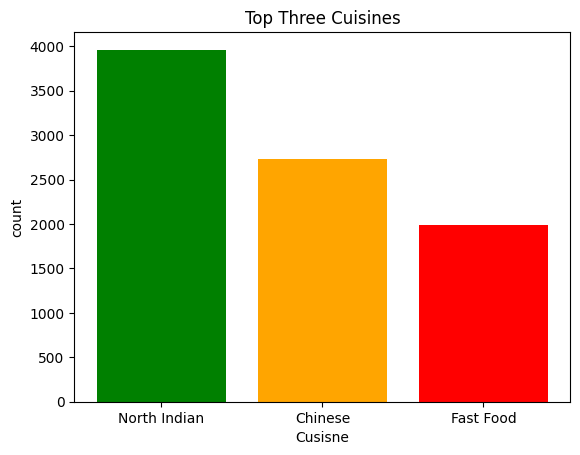

In [9]:
colours = ['green', 'orange', 'red']
plt.bar(top_Cuisine.index, top_Cuisine.values, color=colours)
plt.xlabel('Cusisne')
plt.ylabel('count')
plt.title('Top Three Cuisines')
plt.show()

calculate the percentage of restaurants that serve each of the top cuisines.

In [10]:
total_restaurant = len(df)
print(total_restaurant)
top_Cuisine = Cuisine_count.head()
percentages = (top_Cuisine / total_restaurant) * 100
print("The market share top 5 cuisines are : ", percentages) 

9551
The market share top 5 cuisines are :  Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Mughlai         10.417757
Italian          7.999162
Name: count, dtype: float64


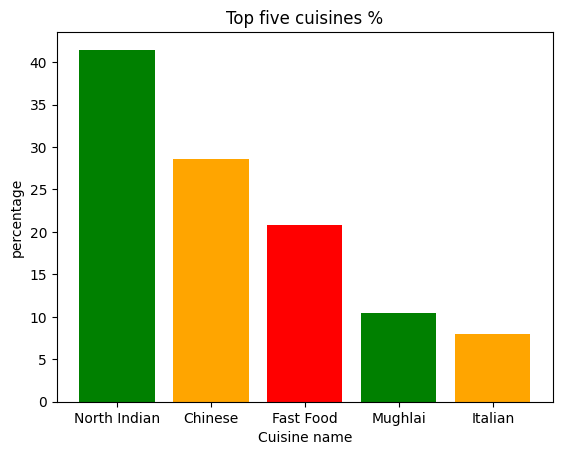

<Figure size 1200x600 with 0 Axes>

In [11]:
plt.bar(top_Cuisine.index, percentages.values, color=colours)
plt.xlabel('Cuisine name')
plt.ylabel('percentage')
plt.title('Top five cuisines %')
plt.figure(figsize=(12,6))
plt.show()

Task2: City Analysis

identify the city with the highest number of restaurants in the dataset.

In [3]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', '@dropdown'],
      dtype='object')


In [7]:
City_count = df['City'].value_counts()
restaurants_no = City_count.head(1)
print("city with the hightest number of restaurants : ", City_count.idxmax())
print(restaurants_no)

city with the hightest number of restaurants :  New Delhi
City
New Delhi    5473
Name: count, dtype: int64


Calculate the average rating for restaurants in each city.

In [9]:

rating_by_each_city = df.groupby('City')['Aggregate rating'].mean()
print("The average rating of each city : ",rating_by_each_city)

The average rating of each city :  City
??stanbul          4.292857
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
                     ...   
Waterloo           3.650000
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
Name: Aggregate rating, Length: 141, dtype: float64


Determine the city with the highest average rating. 

In [10]:
top_rated_city = rating_by_each_city.idxmax()
value = rating_by_each_city.max()
print("The city with highest avg. rating is : ",top_rated_city,",","rating=",value)

The city with highest avg. rating is :  Inner City , rating= 4.9


Task3: Price range distribution

Create a histogram or bar chart to
visualize the distribution of price ranges
among the restaurants.

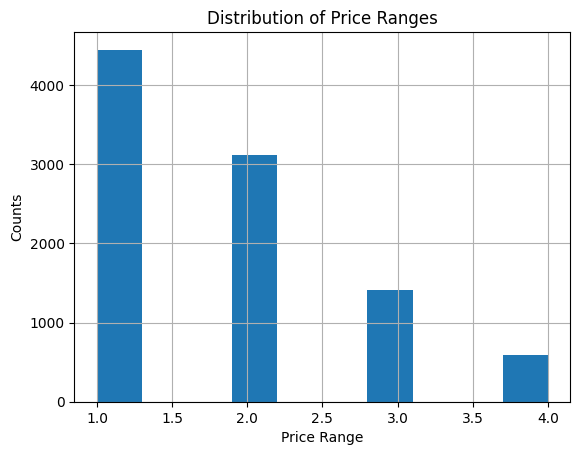

In [11]:
df.hist(column='Price range')
plt.title('Distribution of Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Counts')
plt.show()

Calculate the percentage of restaurants
in each price range category.

In [12]:
price_range_count = df["Price range"].value_counts()
total_restaurant = len(df)
percentage = round((price_range_count/total_restaurant)*100,2)
result = pd.DataFrame({
    "Restaurant Count": price_range_count,
    "Percentage (%)": percentage
})

print("The percentage of restaurants in each price range category:\n")
print(result)

The percentage of restaurants in each price range category:

             Restaurant Count  Percentage (%)
Price range                                  
1                        4444           46.53
2                        3113           32.59
3                        1408           14.74
4                         586            6.14


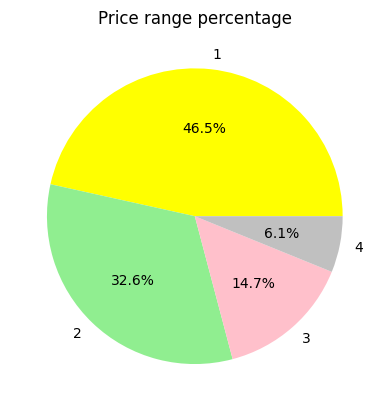

In [14]:
plt.pie(percentage,
        labels=percentage.index,
        autopct='%1.1f%%', 
        colors=["yellow","lightgreen","pink","silver"])
plt.title('Price range percentage')
plt.show()

Task4: Online Delivery


Determine the percentage of restaurants
that offer online delivery.

In [21]:
online_delivery = df['Has Online delivery'].astype(str).str.lower().value_counts().get('yes', 0)
print("Total restaurants with online delivery:", online_delivery)


Total restaurants with online delivery: 2451


In [22]:
online_delivery = df['Has Online delivery'].astype(str).str.lower().value_counts().get('no', 0)
print("Total restaurants with online delivery:", online_delivery)

Total restaurants with online delivery: 7100


In [26]:
online_delivery_count = df["Has Online delivery"].astype(str).str.lower().value_counts()
online_delivery = online_delivery_count.get("yes", 0)
Row_count = len(df)
percentage_of_online_delivery = round((online_delivery / Row_count) * 100, 2)
print("Total % of online Delivery : ", percentage_of_online_delivery, "%")


Total % of online Delivery :  25.66 %


In [ ]:
online_delivery_count = df["Has Online delivery"].astype(str).str.lower().value_counts()
yes = online_delivery_count.get("yes", 0)
no = online_delivery_count.get("no", 0)
Row_count = len(df)
percentage_of_no_online_delivery = round((no / Row_count) * 100, 2)
print("Total % where online delivery is NOT present:", percentage_of_no_online_delivery, "%")


Total % where online delivery is NOT present: 74.34 %


Compare the average ratings of restaurants
with and without online delivery.

In [ ]:
Avg_rating_yes = round(
    df[df['Has Online delivery'].astype(str).str.lower() == 'yes']['Aggregate rating'].mean(),2)
print("Average Rating with online delivery :", Avg_rating_yes)


Average Rating with online delivery : 3.25


In [29]:
Avg_rating_no = round(
    df[df['Has Online delivery'].astype(str).str.lower() == 'no']['Aggregate rating'].mean(),2)
print("Average Rating with online delivery :", Avg_rating_no)

Average Rating with online delivery : 2.47


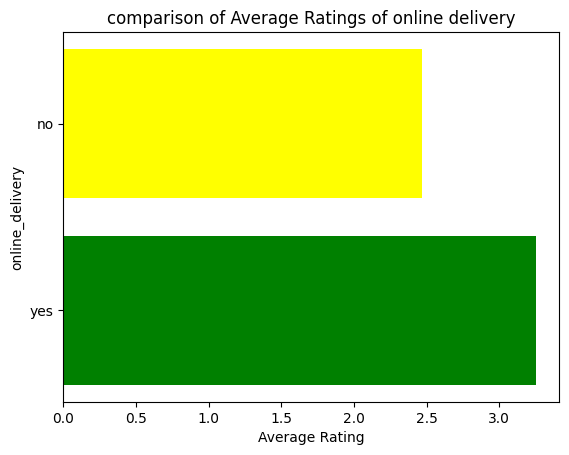

In [30]:
labels = ['yes','no']
Avg_rating = [Avg_rating_yes,Avg_rating_no]
colors = 'green','yellow'
plt.barh(labels,Avg_rating,color=colors)
plt.ylabel('online_delivery')
plt.xlabel('Average Rating')
plt.title('comparison of Average Ratings of online delivery')
plt.show()